# 01 — Data Acquisition & Quality Assessment

Downloads all data from the [Anthropic Economic Index](https://huggingface.co/datasets/Anthropic/EconomicIndex),
along with O*NET occupational data, BLS employment statistics, and O*NET skill ratings.

**Key insight:** The raw data covers 633 occupations but only ~320 have sufficient data
for reliable occupation-level analysis. However, there are **3,259 unique tasks** with
rich continuous measures — this is where the signal lives.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import (
    download_all, load_onet_tasks, load_collaboration_by_task,
    load_unified_release, load_wage_data, load_job_exposure, load_onet_skills,
    build_occupation_panel, build_task_feature_matrix, _build_task_to_soc, RELEASE_FILES,
)

logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

In [2]:
paths = download_all()
print(f"Downloaded {len(paths)}/{len(RELEASE_FILES)} files")

Downloaded 19/19 files


## What the data contains

The AEI provides far more than collaboration mode classifications.
Each task has continuous measures of AI autonomy, education requirements,
time estimates, success rates, and more.

In [3]:
tasks = build_task_feature_matrix()
tasks_unique = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)

print(f"Total task-occupation pairs: {len(tasks):,}")
print(f"Unique tasks: {len(tasks_unique):,}")
print(f"Unique occupations (SOC codes): {tasks['soc_code'].nunique()}")
print(f"\nAvailable measures per task:")
for col in ['ai_autonomy_mean', 'human_education_years', 'ai_education_years',
            'skill_compression', 'human_only_time', 'human_with_ai_time',
            'success_rate', 'human_only_ability_pct', 'automation_share']:
    n = tasks_unique[col].notna().sum()
    print(f"  {col:30s} {n:,} tasks ({n/len(tasks_unique):.0%})")

Total task-occupation pairs: 4,031
Unique tasks: 3,259
Unique occupations (SOC codes): 566

Available measures per task:
  ai_autonomy_mean               3,259 tasks (100%)
  human_education_years          3,259 tasks (100%)
  ai_education_years             3,259 tasks (100%)
  skill_compression              3,259 tasks (100%)
  human_only_time                3,259 tasks (100%)
  human_with_ai_time             3,259 tasks (100%)
  success_rate                   2,739 tasks (84%)
  human_only_ability_pct         3,105 tasks (95%)
  automation_share               3,259 tasks (100%)


## Task coverage: how much of the labor market is represented?

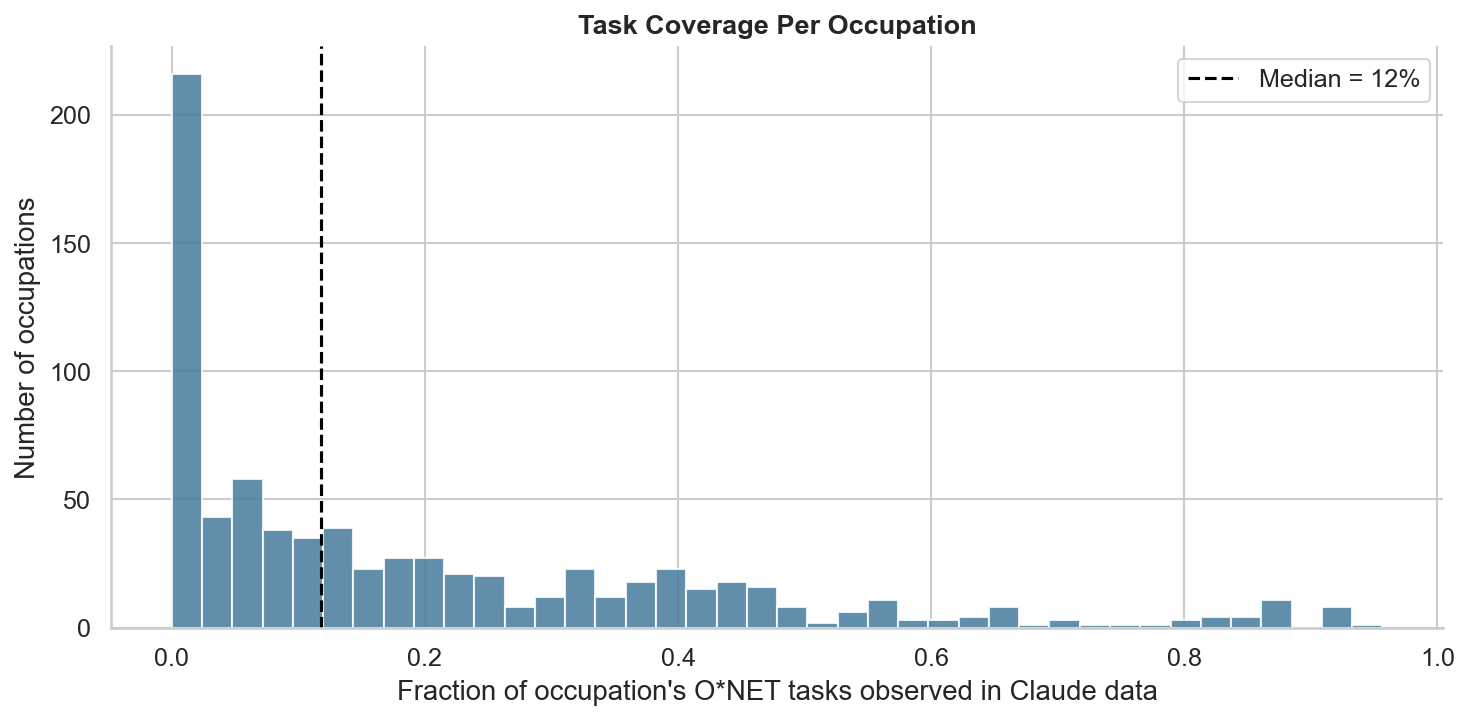

In [4]:
onet = load_onet_tasks()
task_to_soc = _build_task_to_soc()

aei_tasks = set(tasks_unique['task_name'].str.lower().str.strip())
task_to_soc_copy = task_to_soc.copy()
task_to_soc_copy['in_aei'] = task_to_soc_copy['task_name'].isin(aei_tasks)

coverage = (
    task_to_soc_copy.groupby('soc_code')
    .agg(total_tasks=('task_name', 'nunique'), matched_tasks=('in_aei', 'sum'))
    .reset_index()
)
coverage['coverage_pct'] = coverage['matched_tasks'] / coverage['total_tasks']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(coverage['coverage_pct'], bins=40, color='#457B9D', alpha=0.85, edgecolor='white')
ax.axvline(coverage['coverage_pct'].median(), color='black', linestyle='--', linewidth=1.5,
           label=f"Median = {coverage['coverage_pct'].median():.0%}")
ax.set_xlabel("Fraction of occupation's O*NET tasks observed in Claude data")
ax.set_ylabel('Number of occupations')
ax.set_title('Task Coverage Per Occupation', fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../figures/01_task_coverage.png', bbox_inches='tight')
plt.show()

## API vs. Claude.ai: two fundamentally different usage patterns

API usage (programmatic pipelines) is dramatically more automative than interactive Claude.ai use.
This is arguably the most important split in the data.

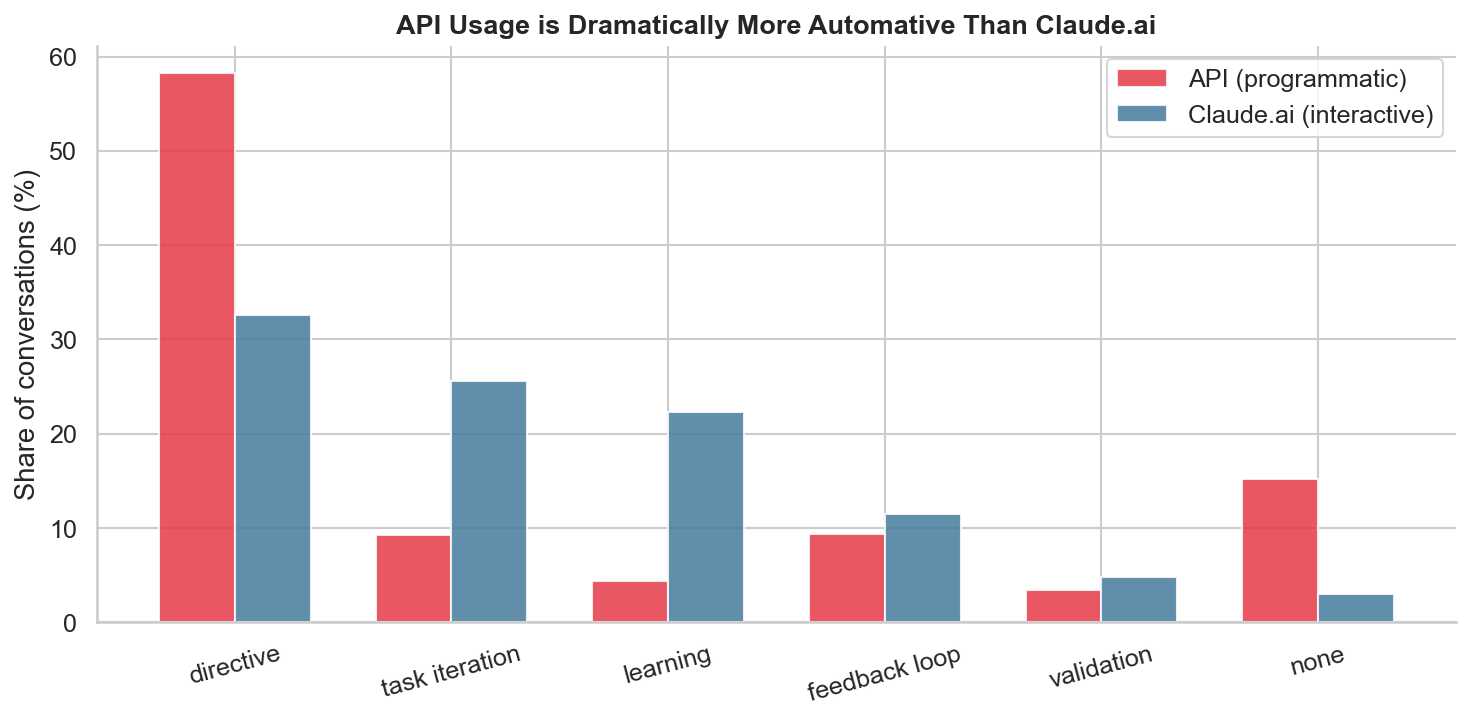

In [5]:
from src.data import AUTOMATION_MODES, AUGMENTATION_MODES

api = load_unified_release('2026_03', platform='api')
claude = load_unified_release('2026_03', platform='claude_ai')

def get_collab_breakdown(df):
    mask = (df['facet'] == 'collaboration') & (df['geography'] == 'global') & (df['variable'].str.contains('pct'))
    return df[mask].set_index('cluster_name')['value']

api_collab = get_collab_breakdown(api)
claude_collab = get_collab_breakdown(claude)

modes_order = ['directive', 'task iteration', 'learning', 'feedback loop', 'validation', 'none']
comparison = pd.DataFrame({'API': api_collab, 'Claude.ai': claude_collab}).reindex(modes_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison))
w = 0.35
ax.bar([i - w/2 for i in x], comparison['API'], w, label='API (programmatic)', color='#E63946', alpha=0.85)
ax.bar([i + w/2 for i in x], comparison['Claude.ai'], w, label='Claude.ai (interactive)', color='#457B9D', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=15)
ax.set_ylabel('Share of conversations (%)')
ax.set_title('API Usage is Dramatically More Automative Than Claude.ai',
             fontsize=13, fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../figures/02_api_vs_claude_ai.png', bbox_inches='tight')
plt.show()

## Preview: the richness of task-level data

Each task has continuous measures that go far beyond simple automation/augmentation classification.

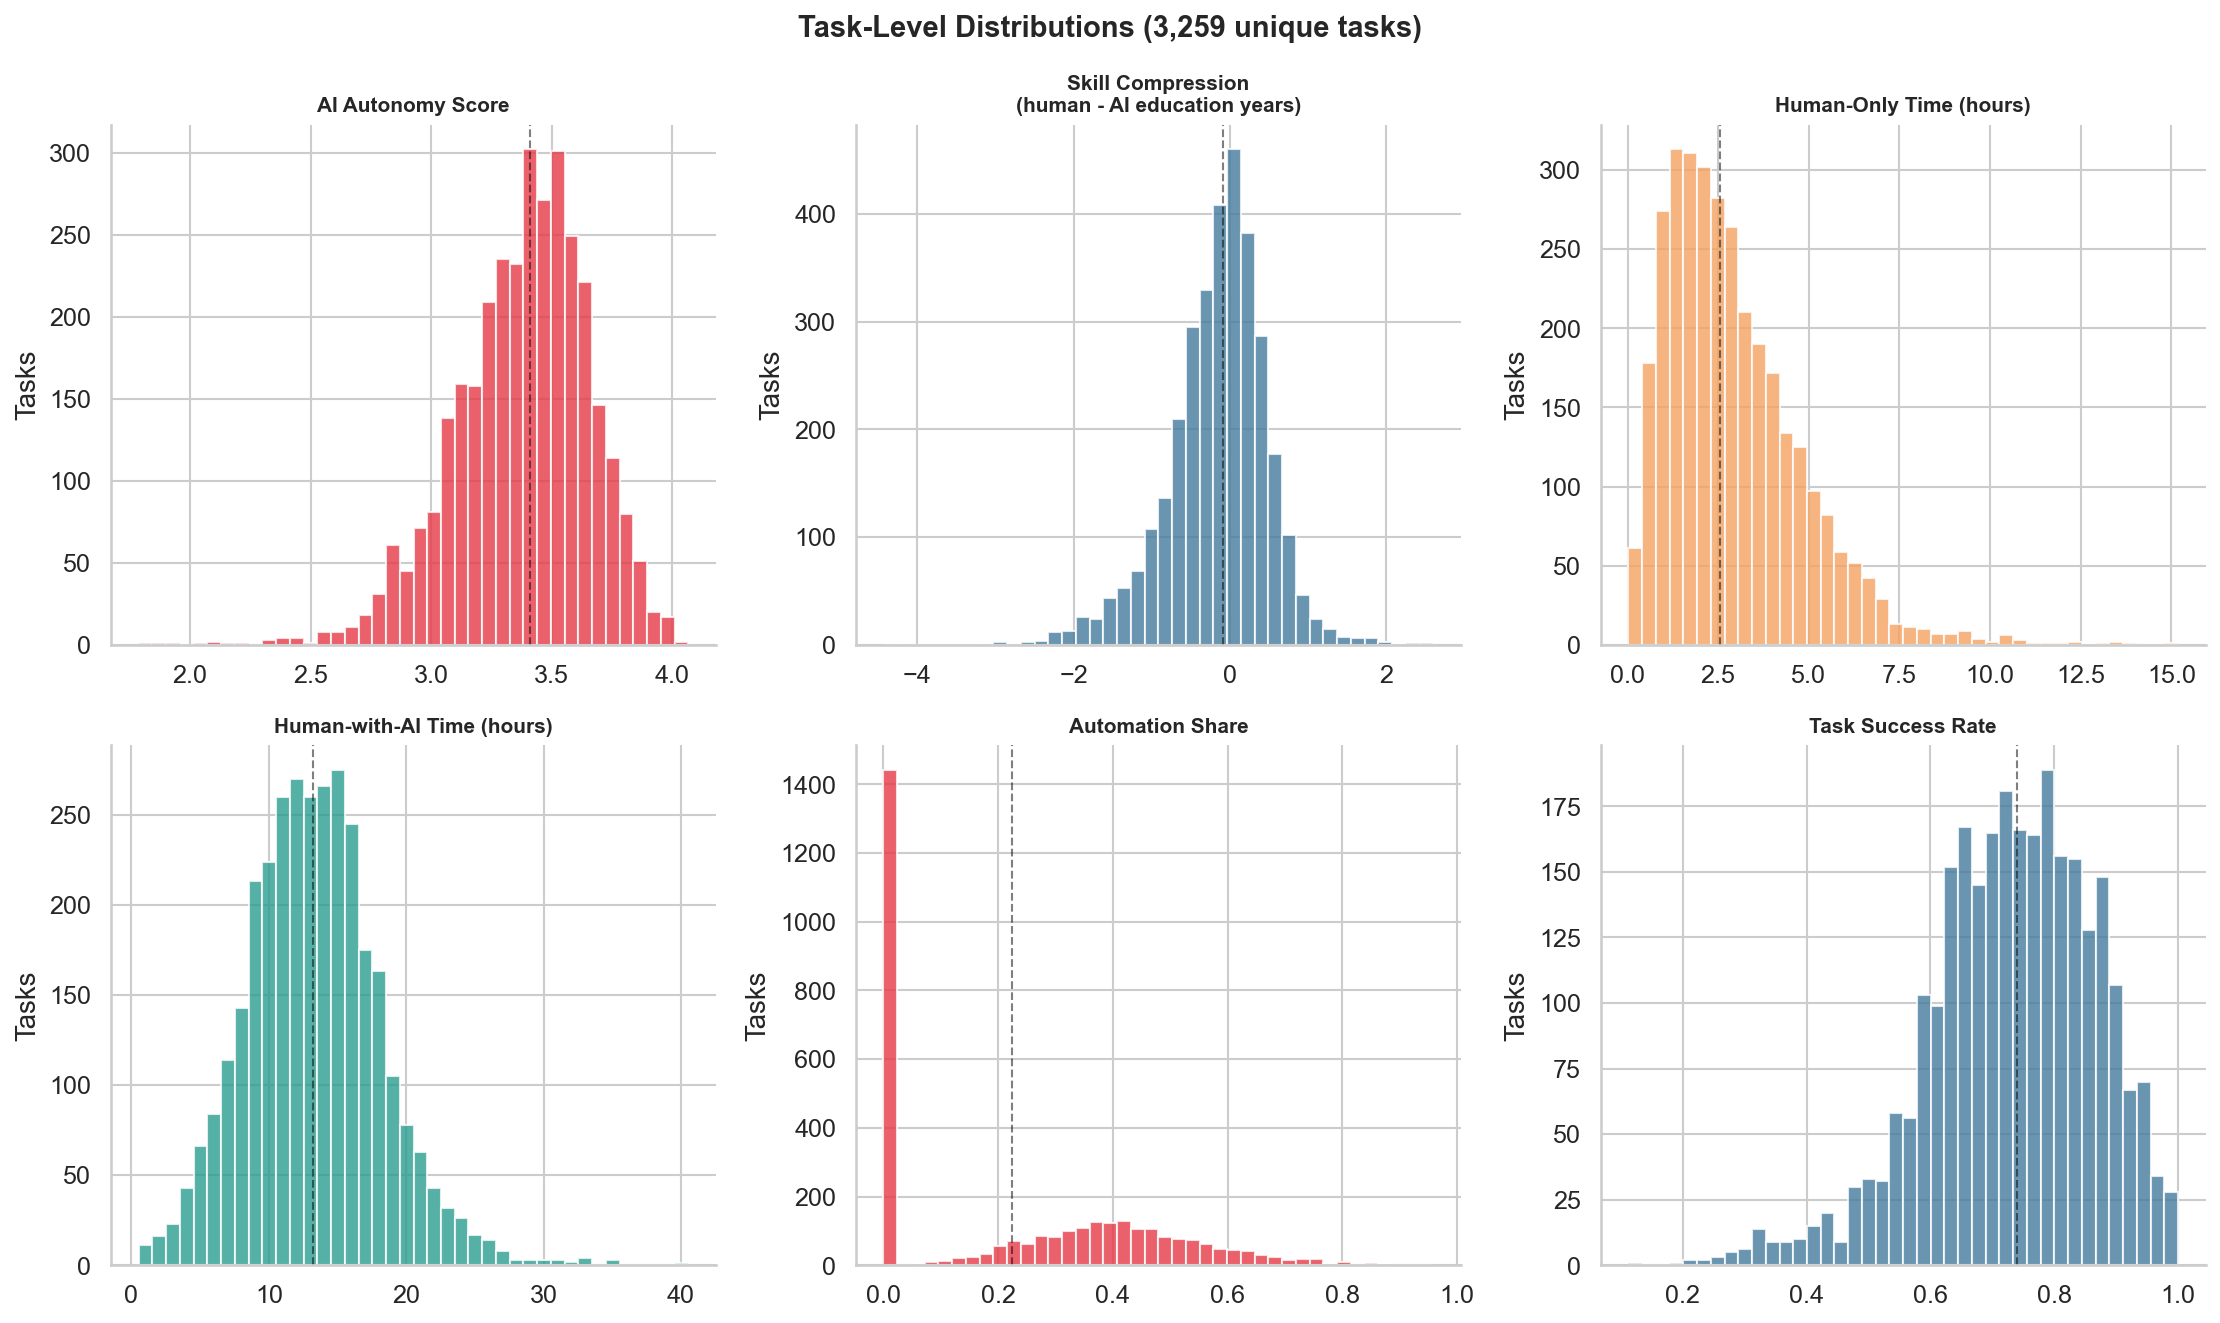

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261'}

plots = [
    ('ai_autonomy_mean', 'AI Autonomy Score', C['auto']),
    ('skill_compression', 'Skill Compression\n(human - AI education years)', C['aug']),
    ('human_only_time', 'Human-Only Time (hours)', C['accent']),
    ('human_with_ai_time', 'Human-with-AI Time (hours)', '#2A9D8F'),
    ('automation_share', 'Automation Share', C['auto']),
    ('success_rate', 'Task Success Rate', C['aug']),
]

for ax, (col, title, color) in zip(axes.flat, plots):
    data = tasks_unique[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Tasks')

plt.suptitle(f'Task-Level Distributions ({len(tasks_unique):,} unique tasks)',
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/03_task_distributions.png', bbox_inches='tight')
plt.show()

---

**Key takeaways:**
1. 3,259 unique tasks with rich continuous measures — 10x more observations than occupation-level
2. API usage is dramatically more automative than Claude.ai — the channel matters
3. Task-level data includes education requirements, time estimates, success rates, and autonomy scores
4. This granularity is where the signal lives — occupation-level aggregation washes it out

**Next:** [02_skill_compression.ipynb](02_skill_compression.ipynb)